In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Load the dataset
data = pd.read_csv('Bengaluru_House_Data.csv')

In [3]:
data.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [4]:
data.shape

(13320, 9)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [6]:
# 3. Check value distributions and unique entries
for column in data.columns:
    print(data[column].value_counts())
    print("*" * 20)
  # it is basically used to in which it goes to first all columns and then count all unique values and then count how many types it appears

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
********************
availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
16-Oct               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64
********************
location
Whitefield                         540
Sarjapur  Road                     399
Electronic City                    302
Kanakpura Road                     273
Thanisandra                        234
                                  ... 
3rd Stage Raja Rajeshwari Nagar      1
Chuchangatta Colony                  1
Electronic City Phase 1,             1
Chikbasavanapura                     1
Abshot Layout                        1
Name: count, Length: 1305, dtype: int64
********************
siz

In [7]:
data.isna().sum()
#it is used to see null values of every column

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [8]:
data.drop(columns=['area_type','availability','society','balcony'],inplace=True)
#we mostly drop that columns that is least important and not usd for data analysis or who have too many null values

In [9]:
data.describe()
#it tells all statisical data about numerical data of dataset

,bath,price
count,13247.000000,13320.000000
mean,2.692610,112.565627
std,1.341458,148.971674
min,1.000000,8.000000
25%,2.000000,50.000000
50%,2.000000,72.000000
75%,3.000000,120.000000
max,40.000000,3600.000000


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13319 non-null  object 
 1   size        13304 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13247 non-null  float64
 4   price       13320 non-null  float64
dtypes: float64(2), object(3)
memory usage: 520.4+ KB


In [11]:
#then start seeing and filling that null values
#1.count null values of every column and fill with suitable data
data['location'].value_counts()

,count
location,
Whitefield,540
Sarjapur Road,399
Electronic City,302
Kanakpura Road,273
Thanisandra,234
...,...
3rd Stage Raja Rajeshwari Nagar,1
Chuchangatta Colony,1
"Electronic City Phase 1,",1


In [12]:
#in location there is only 1 null value so therefore we can put any other but we can't do this with other datatype we can only do it with object'string
data['location'] = data['location'].fillna('Whitefield')
#here we do 1 thing we first go to location in data variable then fill Whitefield to null value and store again in data['location']

In [13]:
data['size'].value_counts()

,count
size,
2 BHK,5199
3 BHK,4310
4 Bedroom,826
4 BHK,591
3 Bedroom,547
1 BHK,538
2 Bedroom,329
5 Bedroom,297
6 Bedroom,191


In [14]:
#in this we see there are 16 null values in size and if there are less null values so we can fill it with data max. appeared also because it is object/string value
data['size']=data['size'].fillna('2 BHK')

In [15]:
#there are 73 null values in bath column so i need to fill it with their median also because it is a numerical data
data['bath']=data['bath'].fillna(data['bath'].median())

In [16]:
#there is 1 more problem in data that there is bhk and bedroom both in size column so we need to fix it as well
data['bhk'] = data['size'].str.split().str.get(0).astype(int)
#in this basically it makes new bhk column in which object first split into 2 object in array and then take object from 0 index and convert it into int type

In [17]:
data[data.bhk > 20]
#basically these are outliers and we need too remove it aswell

,location,size,total_sqft,bath,price,bhk
1718,2Electronic City Phase II,27 BHK,8000,27.0,230.0,27
4684,Munnekollal,43 Bedroom,2400,40.0,660.0,43


In [18]:
#then there is one more problem that there is not only int values in sqft there is also ranges in it so we need to fix it(basically it is object we also need to convert it into float)
data['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [19]:
#we can fix it by take range first and then take both values independently and take mean of both and then this object data convert into float
def convertRange(x):
    temp = x.split('-')
    if len(temp) == 2:
        return (float(temp[0]) + float(temp[1]))/2
    try:
        return float(x)
    except:
      return None

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  object 
 1   size        13320 non-null  object 
 2   total_sqft  13320 non-null  object 
 3   bath        13320 non-null  float64
 4   price       13320 non-null  float64
 5   bhk         13320 non-null  int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 624.5+ KB


In [21]:
data['total_sqft'] = data['total_sqft'].apply(convertRange)
#it convert total sqft object data to float

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  object 
 1   size        13320 non-null  object 
 2   total_sqft  13274 non-null  float64
 3   bath        13320 non-null  float64
 4   price       13320 non-null  float64
 5   bhk         13320 non-null  int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 624.5+ KB


In [23]:
data.describe()

,total_sqft,bath,price,bhk
count,13274.000000,13320.000000,13320.000000,13320.000000
mean,1559.626694,2.688814,112.565627,2.802778
std,1238.405258,1.338754,148.971674,1.294496
min,1.000000,1.000000,8.000000,1.000000
25%,1100.000000,2.000000,50.000000,2.000000
50%,1276.000000,2.000000,72.000000,3.000000
75%,1680.000000,3.000000,120.000000,3.000000
max,52272.000000,40.000000,3600.000000,43.000000


In [24]:
data.head()

,location,size,total_sqft,bath,price,bhk
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3
4,Kothanur,2 BHK,1200.0,2.0,51.00,2


In [25]:
data.drop(columns=['size'], inplace=True)
#here we remove size column(object) as we already convert it into bhk column(float)

In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    13320 non-null  object 
 1   total_sqft  13274 non-null  float64
 2   bath        13320 non-null  float64
 3   price       13320 non-null  float64
 4   bhk         13320 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 520.4+ KB


PRICE PER SQUARE FEET


In [27]:
data['price_per_sqft'] = data['price'] * 100000 / data['total_sqft']
#Basically it makes one more column called price_per_sqft if someone want to buy house by seeing it they can also do

In [28]:
data['price_per_sqft']

,price_per_sqft
0,3699.810606
1,4615.384615
2,4305.555556
3,6245.890861
4,4250.000000
...,...
13315,6689.834926
13316,11111.111111
13317,5258.545136
13318,10407.336319


In [29]:
data.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13274.000000,13320.000000,13320.000000,13320.000000,1.327400e+04
mean,1559.626694,2.688814,112.565627,2.802778,7.907501e+03
std,1238.405258,1.338754,148.971674,1.294496,1.064296e+05
min,1.000000,1.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.266865e+03
50%,1276.000000,2.000000,72.000000,3.000000,5.434306e+03
75%,1680.000000,3.000000,120.000000,3.000000,7.311746e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        13320 non-null  object 
 1   total_sqft      13274 non-null  float64
 2   bath            13320 non-null  float64
 3   price           13320 non-null  float64
 4   bhk             13320 non-null  int64  
 5   price_per_sqft  13274 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 624.5+ KB


In [31]:
data['location'].value_counts()
#here we can see that there are 1305 rows so there is so many and also we see that some of them are even came once only so we need to remove this or replace it

,count
location,
Whitefield,541
Sarjapur Road,399
Electronic City,302
Kanakpura Road,273
Thanisandra,234
...,...
3rd Stage Raja Rajeshwari Nagar,1
Chuchangatta Colony,1
"Electronic City Phase 1,",1


In [32]:
data['location'] = data['location'].apply(lambda x: x.strip())
location_count = data['location'].value_counts()
#here it do one thing basically it sees if any value like whitefiled has space like 'whitefield ' and another 'whitefield' they merge them all as for python both are different

In [33]:
location_count
#now it reduces to 1294


,count
location,
Whitefield,542
Sarjapur Road,399
Electronic City,304
Kanakpura Road,273
Thanisandra,237
...,...
Duddanahalli,1
Doddanakunte,1
Jogupalya,1


In [34]:
location_count_less_10 = location_count[location_count <= 10]
#we put all locations into location_count_less_10 variable which is came less then or equal to 10

In [35]:
data['location'] = data['location'].apply(lambda x: 'other' if x in location_count_less_10 else x)
#here we do one thing ,we rewrite all the values in location_count_less_10 variable to other

In [36]:
location_count_less_10

,count
location,
Basapura,10
Dairy Circle,10
Nagappa Reddy Layout,10
Naganathapura,10
Sector 1 HSR Layout,10
...,...
Duddanahalli,1
Doddanakunte,1
Jogupalya,1


In [37]:
location_count

,count
location,
Whitefield,542
Sarjapur Road,399
Electronic City,304
Kanakpura Road,273
Thanisandra,237
...,...
Duddanahalli,1
Doddanakunte,1
Jogupalya,1


In [38]:
data['location'].value_counts()
#now we can see that there is only 242 rows


,count
location,
other,2885
Whitefield,542
Sarjapur Road,399
Electronic City,304
Kanakpura Road,273
...,...
Tindlu,11
Marsur,11
2nd Phase Judicial Layout,11


OUTLIER DETECTION AND REMOVAL

In [39]:
data.describe()
#here u can see outkiers like 1 sqft that how any house is of 1 sqft

,total_sqft,bath,price,bhk,price_per_sqft
count,13274.000000,13320.000000,13320.000000,13320.000000,1.327400e+04
mean,1559.626694,2.688814,112.565627,2.802778,7.907501e+03
std,1238.405258,1.338754,148.971674,1.294496,1.064296e+05
min,1.000000,1.000000,8.000000,1.000000,2.678298e+02
25%,1100.000000,2.000000,50.000000,2.000000,4.266865e+03
50%,1276.000000,2.000000,72.000000,3.000000,5.434306e+03
75%,1680.000000,3.000000,120.000000,3.000000,7.311746e+03
max,52272.000000,40.000000,3600.000000,43.000000,1.200000e+07


In [40]:
(data['total_sqft']/data['bhk']).describe()

,0
count,13274.000000
mean,575.074878
std,388.205175
min,0.250000
25%,473.333333
50%,552.500000
75%,625.000000
max,26136.000000


In [41]:
data = data[((data['total_sqft']/data['bhk']) >= 300)]
data.describe()
#we store this in data as it is not possible to make bedroom less than 300sqft generally so it can be outlier

,total_sqft,bath,price,bhk,price_per_sqft
count,12530.000000,12530.000000,12530.000000,12530.000000,12530.000000
mean,1594.564544,2.559537,111.382401,2.650838,6303.979357
std,1261.271296,1.077938,152.077329,0.976678,4162.237981
min,300.000000,1.000000,8.440000,1.000000,267.829813
25%,1116.000000,2.000000,49.000000,2.000000,4210.526316
50%,1300.000000,2.000000,70.000000,3.000000,5294.117647
75%,1700.000000,3.000000,115.000000,3.000000,6916.666667
max,52272.000000,16.000000,3600.000000,16.000000,176470.588235


In [42]:
data.shape

(12530, 6)

In [43]:
data.price_per_sqft.describe()
#here max one is outlier so we need to remove it it is done by next function

,price_per_sqft
count,12530.000000
mean,6303.979357
std,4162.237981
min,267.829813
25%,4210.526316
50%,5294.117647
75%,6916.666667
max,176470.588235


In [44]:
# First Function: Price Per Sqft Outlier Remover
def remove_outliers_sqft(df):
    df_output = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        gen_df = subdf[(subdf.price_per_sqft > (m-st)) & (subdf.price_per_sqft <= (m+st))]
        df_output = pd.concat([df_output, gen_df], ignore_index=True)
    return df_output

data = remove_outliers_sqft(data)
data.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,10301.000000,10301.000000,10301.000000,10301.000000,10301.000000
mean,1508.440608,2.471702,91.286372,2.574896,5659.062876
std,880.694214,0.979449,86.342786,0.897649,2265.774749
min,300.000000,1.000000,10.000000,1.000000,1250.000000
25%,1110.000000,2.000000,49.000000,2.000000,4244.897959
50%,1286.000000,2.000000,67.000000,2.000000,5175.600739
75%,1650.000000,3.000000,100.000000,3.000000,6428.571429
max,30400.000000,16.000000,2200.000000,16.000000,24509.803922


In [45]:
#Second Function: BHK Price Outlier Remover
def bhk_outlier_remover(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                exclude_indices = np.append(exclude_indices, bhk_df[bhk_df.price_per_sqft<(stats['mean'])].index.values)
    return df.drop(exclude_indices, axis='index')

In [46]:
data = bhk_outlier_remover(data)

In [47]:
data.shape

(7361, 6)

In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7361 entries, 0 to 10300
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        7361 non-null   object 
 1   total_sqft      7361 non-null   float64
 2   bath            7361 non-null   float64
 3   price           7361 non-null   float64
 4   bhk             7361 non-null   int64  
 5   price_per_sqft  7361 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 402.6+ KB


In [49]:
data

,location,total_sqft,bath,price,bhk,price_per_sqft
0,1st Block Jayanagar,2850.0,4.0,428.0,4,15017.543860
1,1st Block Jayanagar,1630.0,3.0,194.0,3,11901.840491
2,1st Block Jayanagar,1875.0,2.0,235.0,3,12533.333333
3,1st Block Jayanagar,1200.0,2.0,130.0,3,10833.333333
4,1st Block Jayanagar,1235.0,2.0,148.0,2,11983.805668
...,...,...,...,...,...,...
10292,other,1200.0,2.0,70.0,2,5833.333333
10293,other,1800.0,1.0,200.0,1,11111.111111
10296,other,1353.0,2.0,110.0,2,8130.081301
10297,other,812.0,1.0,26.0,1,3201.970443


In [50]:
data.drop(columns=['price_per_sqft'], inplace=True)
#here i need to rem=move this price per sqft as its work done which is used to remove outliers

In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7361 entries, 0 to 10300
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   location    7361 non-null   object 
 1   total_sqft  7361 non-null   float64
 2   bath        7361 non-null   float64
 3   price       7361 non-null   float64
 4   bhk         7361 non-null   int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 345.0+ KB


CLEANED DATA

In [52]:
data.head()

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3
3,1st Block Jayanagar,1200.0,2.0,130.0,3
4,1st Block Jayanagar,1235.0,2.0,148.0,2


In [53]:
data.to_csv("Cleaned_data.csv")

In [54]:
X = data.drop(columns=['price'])
y = data['price']
#put price in one variable other all data in another variable

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [57]:
print(X_train.shape)
print(X_test.shape)

(5888, 4)
(1473, 4)


LINEAR REGRESSION


In [58]:
# 1. Setup the Column Transformer for text data
column_trans = make_column_transformer(
    (OneHotEncoder(sparse_output=False), ['location']),
    remainder='passthrough'
)

In [59]:
# 2. Setup the Numerical Scaler
scaler = StandardScaler()

In [60]:
# 3. Initialize the Linear Regression Model (Fixed for modern sklearn)
lr = LinearRegression()

In [61]:
# 4. Link them together into an automated pipeline conveyor belt
pipe = make_pipeline(column_trans, scaler, lr)

In [62]:
pipe.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('onehotencoder',
                                                  OneHotEncoder(sparse_output=False),
                                                  ['location'])])),
                ('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])

In [63]:
y_pred_lr = pipe.predict(X_test)

In [64]:
r2_score(y_test, y_pred_lr)

0.8251977016381459

In [65]:
from sklearn.metrics import mean_absolute_error

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred_lr)
print(f"Linear Regression MAE: {mae:.2f} Lakhs")

Linear Regression MAE: 18.10 Lakhs


In [66]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = pipe.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.2f} Lakhs")
print(f"RMSE     : {rmse:.2f} Lakhs")

R² Score : 0.8252
MAE      : 18.10 Lakhs
RMSE     : 35.62 Lakhs


In [67]:
# 1. Define your custom house values here
custom_house = {
    'location': 'Whitefield',      # The neighborhood name (exactly as it appears in your data)
    'total_sqft': 2000,            # Total area in square feet
    'bath': 3.0,                   # Number of bathrooms
    'bhk': 5                       # Number of bedrooms
}

# 2. Convert the dictionary into a pandas DataFrame (Single Row)
# The column names MUST match your X_train columns exactly
input_df = pd.DataFrame([custom_house])

# 3. Use your trained pipeline to predict the price
predicted_price = pipe.predict(input_df)[0]

# 4. Display the final result
print("--- House Price Prediction Tool ---")
print(f"Location: {custom_house['location']}")
print(f"Features: {custom_house['bhk']} BHK, {custom_house['bath']} Bath, {custom_house['total_sqft']} Sqft")
print(f"Estimated Price: {predicted_price:.2f} Lakhs")
print("-----------------------------------")

--- House Price Prediction Tool ---
Location: Whitefield
Features: 5 BHK, 3.0 Bath, 2000 Sqft
Estimated Price: 129.23 Lakhs
-----------------------------------


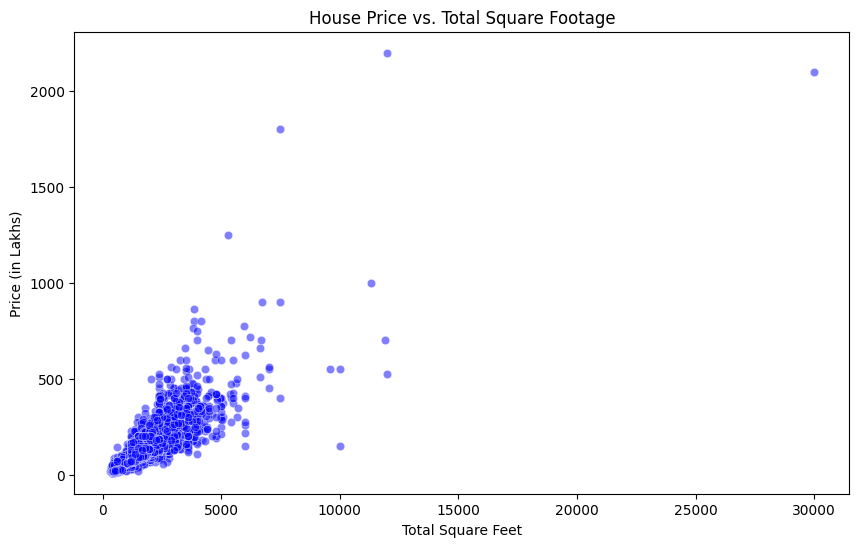

In [68]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_sqft', y='price', data=data, alpha=0.5, color='blue')
plt.title('House Price vs. Total Square Footage')
plt.xlabel('Total Square Feet')
plt.ylabel('Price (in Lakhs)')
plt.show()

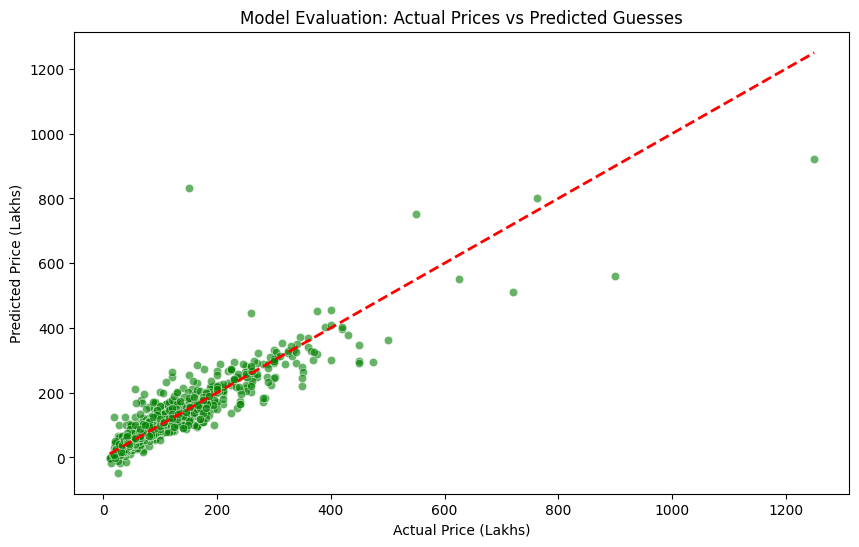

In [69]:
plt.figure(figsize=(10, 6))
# Plot the actual vs predicted values
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6, color='green')

# Plot a perfect diagonal reference line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

plt.title('Model Evaluation: Actual Prices vs Predicted Guesses')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.show()

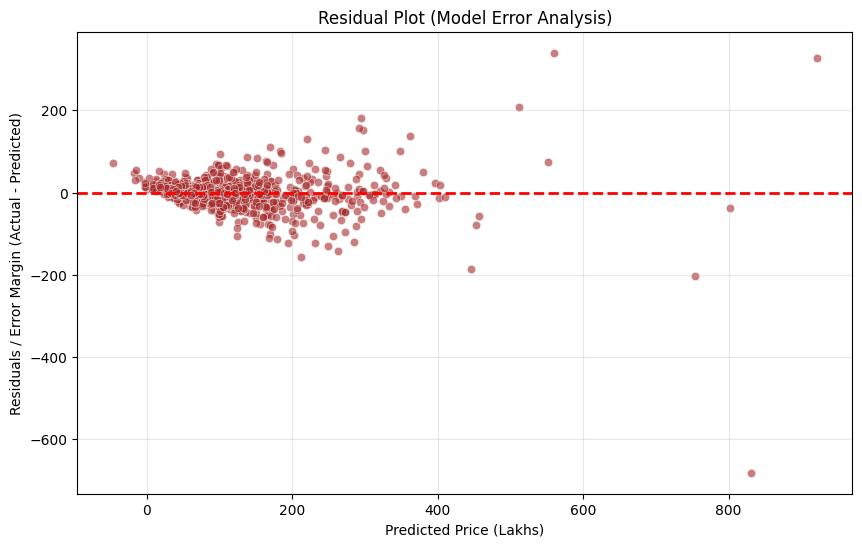

In [70]:
# 1. Calculate the raw errors (Residuals)
residuals = y_test - y_pred_lr

# 2. Set up the plotting canvas
plt.figure(figsize=(10, 6))

# 3. Create the scatter plot of residuals
sns.scatterplot(x=y_pred_lr, y=residuals, alpha=0.6, color='brown')

# 4. Add a horizontal line at 0 (The "Perfect Guess" line)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# 5. Labels and Titles
plt.title('Residual Plot (Model Error Analysis)')
plt.xlabel('Predicted Price (Lakhs)')
plt.ylabel('Residuals / Error Margin (Actual - Predicted)')
plt.grid(True, alpha=0.3)

plt.show()

Price distribution


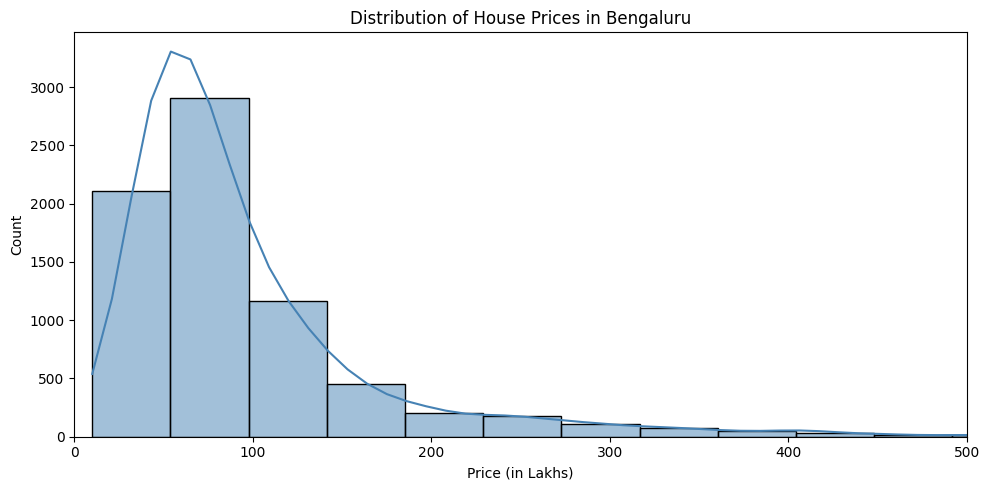

In [71]:
plt.figure(figsize=(10, 5))
sns.histplot(data['price'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of House Prices in Bengaluru')
plt.xlabel('Price (in Lakhs)')
plt.ylabel('Count')
plt.xlim(0, 500)
plt.tight_layout()
plt.show()

BHK count plot


/tmp/ipykernel_1184/1505972137.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bhk_counts.index, y=bhk_counts.values, palette='Blues_d')


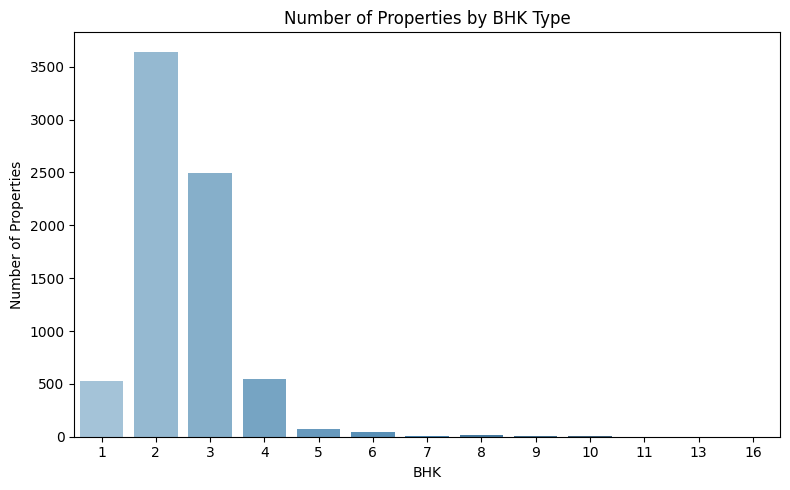

In [72]:
plt.figure(figsize=(8, 5))
bhk_counts = data['bhk'].value_counts().sort_index()
sns.barplot(x=bhk_counts.index, y=bhk_counts.values, palette='Blues_d')
plt.title('Number of Properties by BHK Type')
plt.xlabel('BHK')
plt.ylabel('Number of Properties')
plt.tight_layout()
plt.show()

Price vs total sqft (scatter)

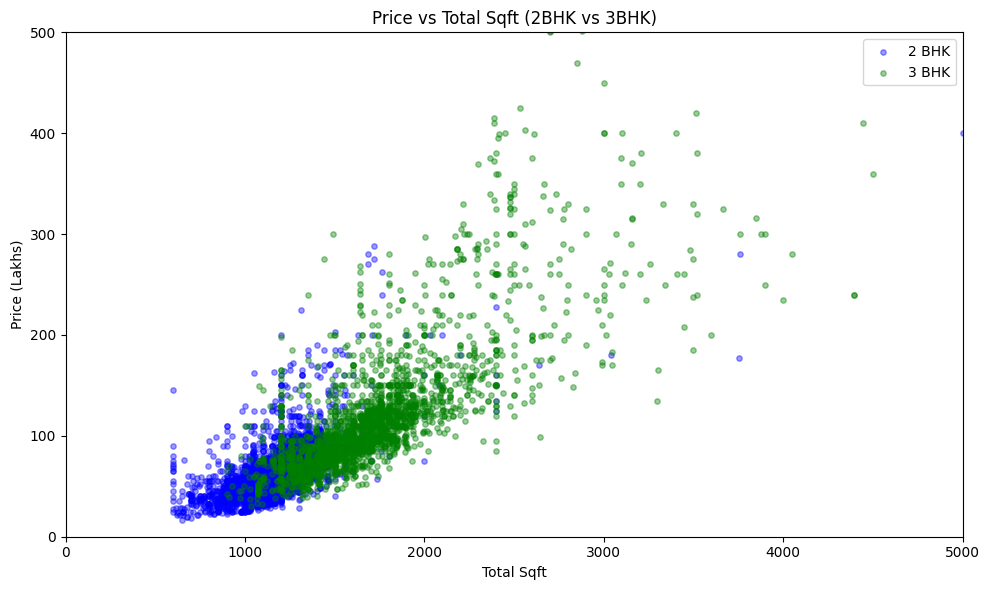

In [73]:
plt.figure(figsize=(10, 6))
bhk2 = data[data['bhk'] == 2]
bhk3 = data[data['bhk'] == 3]
plt.scatter(bhk2['total_sqft'], bhk2['price'],
            color='blue', alpha=0.4, label='2 BHK', s=15)
plt.scatter(bhk3['total_sqft'], bhk3['price'],
            color='green', alpha=0.4, label='3 BHK', s=15)
plt.title('Price vs Total Sqft (2BHK vs 3BHK)')
plt.xlabel('Total Sqft')
plt.ylabel('Price (Lakhs)')
plt.xlim(0, 5000)
plt.ylim(0, 500)
plt.legend()
plt.tight_layout()
plt.show()

Top 10 locations by avg price

/tmp/ipykernel_1184/1678179384.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index,


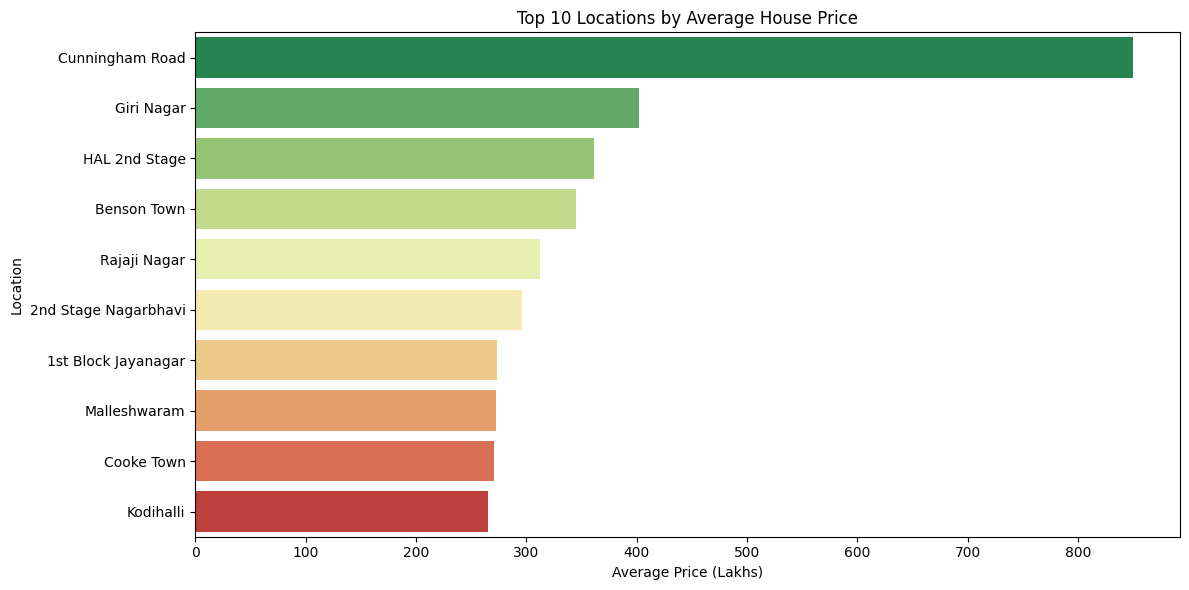

In [74]:
plt.figure(figsize=(12, 6))
top_locations = (data.groupby('location')['price']
                 .mean()
                 .sort_values(ascending=False)
                 .head(10))
sns.barplot(x=top_locations.values, y=top_locations.index,
            palette='RdYlGn_r')
plt.title('Top 10 Locations by Average House Price')
plt.xlabel('Average Price (Lakhs)')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

Correlation heatmap

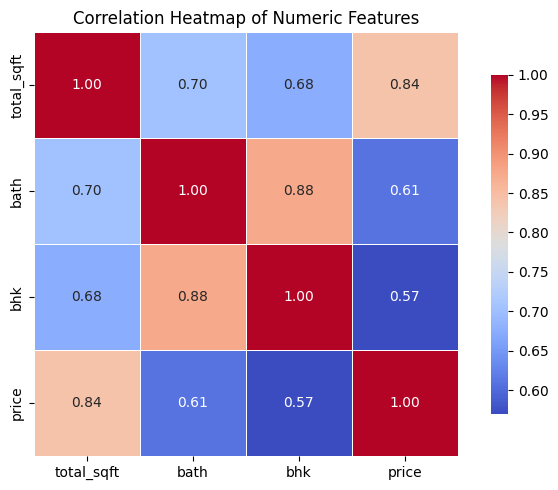

In [75]:
plt.figure(figsize=(7, 5))
corr_cols = ['total_sqft', 'bath', 'bhk', 'price']
corr_matrix = data[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

Boxplot: price by BHK

/tmp/ipykernel_1184/2021308069.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bhk', y='price', data=filtered,


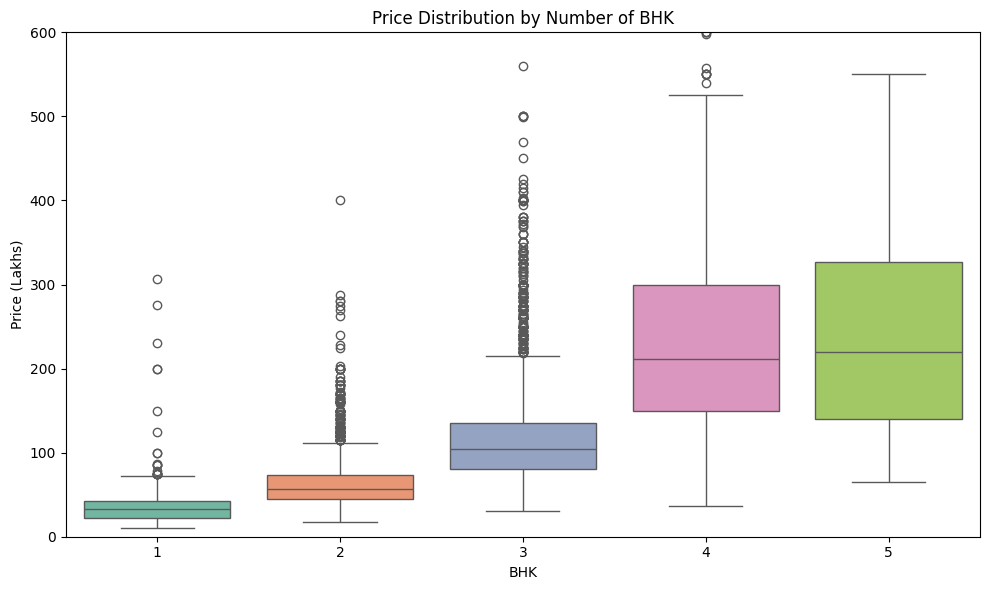

In [76]:
plt.figure(figsize=(10, 6))
filtered = data[data['bhk'].isin([1, 2, 3, 4, 5])]
sns.boxplot(x='bhk', y='price', data=filtered,
            palette='Set2')
plt.title('Price Distribution by Number of BHK')
plt.xlabel('BHK')
plt.ylabel('Price (Lakhs)')
plt.ylim(0, 600)
plt.tight_layout()
plt.show()

Price per sqft distribution

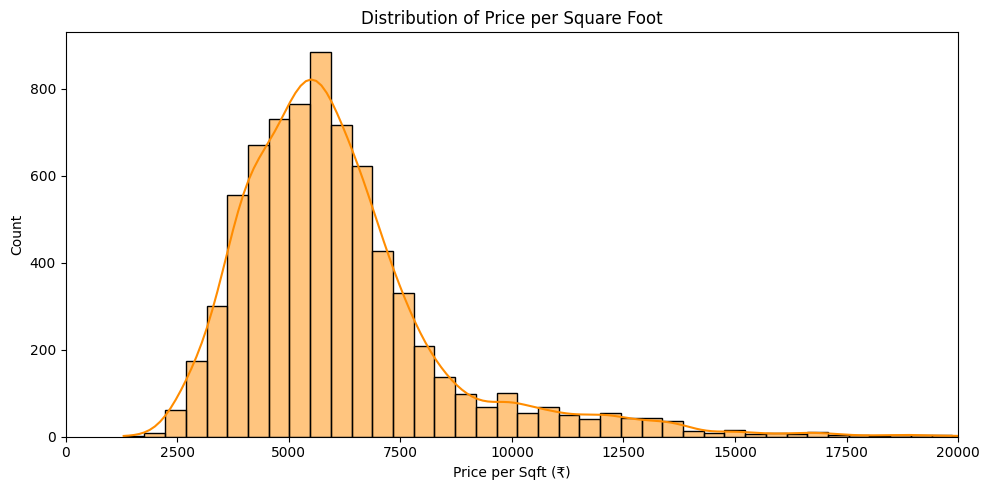

In [77]:
data['price_per_sqft'] = data['price'] * 100000 / data['total_sqft']

plt.figure(figsize=(10, 5))
sns.histplot(data['price_per_sqft'], bins=50,
             kde=True, color='darkorange')
plt.title('Distribution of Price per Square Foot')
plt.xlabel('Price per Sqft (₹)')
plt.xlim(0, 20000)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [78]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 80.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 71.8 MB/s eta 0:00:00


In [79]:
import pickle
import json

# Save model
with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(pipe, f)

# Save locations
locations = sorted(data['location'].unique().tolist())
with open('locations.json', 'w') as f:
    json.dump(locations, f)

print("✅ Model saved!")

✅ Model saved!


In [80]:
app_code = """
import streamlit as st
import pickle
import json
import pandas as pd

with open("house_price_model.pkl", "rb") as f:
    pipe = pickle.load(f)

with open("locations.json", "r") as f:
    locations = json.load(f)

st.set_page_config(page_title="House Price Predictor", page_icon="🏠", layout="centered")

st.title("🏠 Bengaluru House Price Predictor")
st.markdown("#### Predict house prices using Machine Learning!")
st.markdown("*BSc DS&AI · IIT Guwahati · DA378*")
st.divider()

location = st.selectbox("📍 Select Location", locations)

col1, col2 = st.columns(2)
with col1:
    bhk = st.selectbox("🛏 BHK", [1, 2, 3, 4, 5])
with col2:
    bath = st.selectbox("🚿 Bathrooms", [1, 2, 3, 4, 5])

total_sqft = st.slider("📐 Total Square Feet", min_value=300, max_value=8000, value=1200, step=100)

st.divider()

if st.button("🔮 Predict Price", use_container_width=True):
    input_df = pd.DataFrame([{
        "location": location,
        "total_sqft": total_sqft,
        "bath": float(bath),
        "bhk": bhk
    }])

    predicted_price = pipe.predict(input_df)[0]
    price_per_sqft = (predicted_price * 100000) / total_sqft

    st.success(f"💰 Estimated Price: ₹ {predicted_price:.2f} Lakhs")
    st.info(f"📊 Price per Sqft: ₹ {price_per_sqft:,.0f}")

    st.markdown("---")
    st.markdown("**Your Input Summary:**")
    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Location", location)
    c2.metric("BHK", bhk)
    c3.metric("Bathrooms", bath)
    c4.metric("Sqft", total_sqft)

st.divider()
st.caption("Bengaluru House Dataset · ML Pipeline · IIT Guwahati Project")
"""

with open("app.py", "w") as f:
    f.write(app_code)

print("✅ app.py created!")

✅ app.py created!


In [81]:
from getpass import getpass
token = getpass("Enter your NEW ngrok token: ")
!ngrok authtoken {token}

Enter your NEW ngrok token: ··········
Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [82]:
from pyngrok import ngrok
import subprocess
import time

subprocess.Popen(
    ["streamlit", "run", "app.py",
     "--server.port", "8501",
     "--server.headless", "true"]
)

time.sleep(3)

public_url = ngrok.connect(8501)
print("=" * 40)
print("✅ APP IS LIVE!")
print(f"🌐 Link: {public_url}")
print("=" * 40)

✅ APP IS LIVE!
🌐 Link: NgrokTunnel: "https://divided-unearth-swarm.ngrok-free.dev" -> "http://localhost:8501"


In [85]:
import sklearn, pandas, joblib, streamlit ,numpy
print("scikit-learn:", sklearn.__version__)
print("pandas:", pandas.__version__)
print("joblib:", joblib.__version__)
print("streamlit:", streamlit.__version__)
print("numpy:", numpy.__version__)

scikit-learn: 1.6.1
pandas: 2.2.3
joblib: 1.6.0
streamlit: 1.64.0
numpy: 2.1.3
